The main objective is to analyze the event log data and find the decision places via token replay using alignments beforehand.
But using now our bpmn because of the a lot of skip and tau in the event log that can mislead us.

In [137]:
import sys
import os
import pm4py
import pandas as pd
import json
import graphviz
from pm4py.algo.conformance.tokenreplay import algorithm as token_replay
from pm4py.algo.discovery.inductive import algorithm as inductive_miner 
from pm4py.objects.conversion.process_tree import converter as pt_converter
from pm4py.objects.petri_net.semantics import enabled_transitions, execute
from c45_tree import C45DecisionTree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, balanced_accuracy_score


In [138]:
current_dir = os.getcwd()
sim_core_path = os.path.abspath(os.path.join(current_dir, '..', 'sim_core'))
if sim_core_path not in sys.path:
    sys.path.append(sim_core_path)
try:
    from pn_model import PNModel, wrap_net
    from bpmn_io import read_bpmn
    
except ImportError as e:
    print(f"Error: {e}")

In [139]:
bpmn_path = "../data/process_model.bpmn"
log_path = "../data/BPI Challenge 2017.xes.gz"

In [140]:
#net, im, fm = read_bpmn(bpmn_path)

In [141]:
log_path = "../data/BPI Challenge 2017.xes.gz"
log = pm4py.read_xes(log_path)

In [142]:
bpmn_graph = pm4py.read_bpmn(bpmn_path)

In [143]:
log_activities = set(log['concept:name'].unique())
bpmn_labels = set()
for node in bpmn_graph.get_nodes():
    if node.get_name() and node.get_name().strip() != "":
        bpmn_labels.add(node.get_name().strip())

missing_in_bpmn = log_activities - bpmn_labels
missing_in_bpmn

{'O_Sent (online only)',
 'W_Assess potential fraud',
 'W_Personal Loan collection',
 'W_Shortened completion '}

In [144]:
#replayed_traces = token_replay.apply(log, net, im, fm)

In [145]:
#df_replay_stats = pd.DataFrame(replayed_traces)
#display(df_replay_stats)
#avg_fitness = df_replay_stats['trace_fitness'].mean()
#avg_fitness

It is normal to get such as average fitness because as we discovered: we didnt model these activites in our bpmn 'O_Sent (online only)',
 'W_Assess potential fraud',
 'W_Personal Loan collection',
 'W_Shortened completion '
Otherwise, the data would be too noisy

In [146]:
#replayed_traces

In [147]:
#df_replay = pd.DataFrame(replayed_traces)
#fit_traces = df_replay[df_replay['trace_is_fit'] == True]
#fit_traces

Decided to the training with event log 

In [148]:
df = pm4py.convert_to_dataframe(log)
print(f"Loaded {len(df)} events.")
df_log = pm4py.convert_to_dataframe(log)

Loaded 1202267 events.


In [149]:
df_log['time:timestamp'] = pd.to_datetime(df_log['time:timestamp'])
df_log = df_log.sort_values(['case:concept:name', 'time:timestamp'])    

In [150]:
tree = inductive_miner.apply(log)

net, initial_marking, final_marking = pt_converter.apply(tree)

In [151]:
replayed_log = token_replay.apply(log, net, initial_marking, final_marking)

replaying log with TBR, completed traces :: 100%|██████████| 15930/15930 [00:35<00:00, 451.78it/s]


In [152]:
event_log = pm4py.convert_to_event_log(log)

(skip_37, None),(skip_38, None),(tauSplit_40, None),(skip_48, None), etc. are the silent transitions that probably lead to a XOR

In [153]:
decision_training_data = []

# replayed_traces listesi ile event_log listesi birebir aynı sıradadır
for trace_idx, trace in enumerate(event_log):
    # Bu trace için hesaplanmış geçerli yolu alıyoruz
    replay_result = replayed_log[trace_idx]
    
    # Token replay'in bulduğu ateşlenen geçişler listesi (Sessizler dahil!)
    fired_transitions = replay_result['activated_transitions']
    
    # Trace içindeki gerçek eventler için bir sayaç (sadece görünür geçişlerde artacak)
    event_idx = 0
    
    case_id = trace.attributes.get('concept:name')
    case_start_time = trace[0]['time:timestamp']
    current_marking = initial_marking.copy()
    
    for t in fired_transitions:
        # 1. Şu anki durumda Karar Noktası var mı?
        enabled = enabled_transitions(net, current_marking)
        
        # Eğer birden fazla yol varsa ve bu bir "Split" ise
        if len(enabled) > 1:
            # Şu anki geçiş görünür mü (label'ı var mı?) yoksa sessiz mi?
            # Karar noktası sessiz bir geçişle de başlayabilir, önemli olan yol ayrımı olması.
            
            # Veri toplamak için logdaki "son" duruma bakmamız lazım
            # Not: event_idx henüz işlenmemiş eventi gösterir, o yüzden bir öncekini (i-1) almak için:
            if event_idx > 0 and event_idx < len(trace):
                prev_event = trace[event_idx - 1]
                curr_event = trace[event_idx] # Hedeflenen gerçek aktivite (eğer t görünürse)
            
                decision_label = t.label if t.label else t.name
                
                features = {
                    "case_id": case_id,
                    "prev_activity": prev_event['concept:name'],
                    "last_resource": prev_event.get('org:resource', 'System'),
                    "last_duration": (curr_event['time:timestamp'] - prev_event['time:timestamp']).total_seconds(),
                    "case_duration_hours": (curr_event['time:timestamp'] - case_start_time).total_seconds() / 3600,
                    "target_decision": decision_label # Artık target, seçilen yolun adıdır
                }
                decision_training_data.append(features)

        # State
        current_marking = execute(t, net, current_marking)
        
        if t.label is not None:
            event_idx += 1

df_xor_decisions = pd.DataFrame(decision_training_data)

print(f"Toplam Karar Satırı: {len(df_xor_decisions)}")
print(f"Benzersiz Önceki Aktiviteler: {df_xor_decisions['prev_activity'].nunique()}")
print(f"Benzersiz Hedef Kararlar: {df_xor_decisions['target_decision'].nunique()}")

Toplam Karar Satırı: 2819057
Benzersiz Önceki Aktiviteler: 26
Benzersiz Hedef Kararlar: 83


In [154]:
df_xor_decisions.head()

,case_id,prev_activity,last_resource,last_duration,case_duration_hours,target_decision
0,Application_652823628,A_Create Application,User_1,0.048,0.000013,A_Submitted
1,Application_652823628,A_Submitted,User_1,0.422,0.000131,init_loop_11
2,Application_652823628,A_Submitted,User_1,0.422,0.000131,W_Handle leads
3,Application_652823628,W_Handle leads,User_1,80.618,0.022524,skip_13
4,Application_652823628,W_Handle leads,User_1,80.618,0.022524,W_Handle leads


In [155]:
# Target Activities with silent transitions
print(df_xor_decisions['target_decision'].value_counts().head(30))

target_decision
W_Call after offers         179625
skip_25                     148742
W_Complete application      147848
skip_65                     134654
W_Validate application      117067
skip_72                     116345
skip_35                      88572
skip_70                      87475
skip_19                      84588
tauSplit_40                  77274
W_Call incomplete files      71866
tauJoin_41                   69808
skip_36                      69313
skip_48                      64408
skip_39                      63326
tauSplit_20                  63003
skip_42                      62594
init_loop_29                 60428
skip_45                      58850
init_loop_33                 47754
W_Handle leads               47208
skip_71                      47179
skip_37                      41980
skip_38                      41936
O_Create Offer               40923
O_Created                    40724
skip_31                      39376
O_Sent (mail and online)     37983
skip

In order to train the C4.5 decision tree, we need first training data

In [156]:
df_xor_decisions.head()

,case_id,prev_activity,last_resource,last_duration,case_duration_hours,target_decision
0,Application_652823628,A_Create Application,User_1,0.048,0.000013,A_Submitted
1,Application_652823628,A_Submitted,User_1,0.422,0.000131,init_loop_11
2,Application_652823628,A_Submitted,User_1,0.422,0.000131,W_Handle leads
3,Application_652823628,W_Handle leads,User_1,80.618,0.022524,skip_13
4,Application_652823628,W_Handle leads,User_1,80.618,0.022524,W_Handle leads


In [157]:
df_xor_decisions['prev_activity'].nunique()


26

In [158]:
df_xor_decisions['target_decision'].nunique()

83

In [159]:
# For a target look at the distribution of prev_activity
display(df_xor_decisions.groupby('target_decision')['prev_activity'].value_counts())
matrix_view = pd.crosstab(df_xor_decisions['target_decision'], df_xor_decisions['prev_activity'])
matrix_view

target_decision  prev_activity             
A_Accepted       W_Complete application        9606
                 W_Handle leads                6112
                 A_Concept                     3890
                 O_Created                     2659
                 O_Create Offer                2415
                                               ... 
tauSplit_40      A_Denied                       192
                 O_Sent (online only)           135
                 W_Assess potential fraud       123
                 W_Shortened completion          26
                 W_Personal Loan collection       1
Name: count, Length: 1630, dtype: int64

prev_activity,A_Accepted,A_Cancelled,A_Complete,A_Concept,A_Create Application,A_Denied,A_Incomplete,A_Pending,A_Submitted,A_Validating,...,O_Sent (mail and online),O_Sent (online only),W_Assess potential fraud,W_Call after offers,W_Call incomplete files,W_Complete application,W_Handle leads,W_Personal Loan collection,W_Shortened completion,W_Validate application
target_decision,,,,,,,,,,,,,,,,,,,,,
A_Accepted,2058,26,451,3890,0,3,4,1,0,19,...,1705,36,15,2212,14,9606,6112,0,11,118
A_Cancelled,62,193,588,0,0,23,104,45,0,395,...,313,7,8,3232,427,454,6,0,7,1689
A_Complete,917,331,2171,26,0,16,43,18,0,428,...,2804,32,8,12592,186,4414,41,0,14,1757
A_Concept,4958,0,7,142,3389,0,0,0,0,2,...,60,2,14,79,1,14819,7020,0,1,6
A_Denied,5,25,28,0,0,11,80,44,0,113,...,29,2,11,226,485,19,0,0,0,606
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
tauJoin_21,2407,172,1833,701,0,16,12,8,0,153,...,3968,83,8,8079,72,7936,107,0,14,701
tauJoin_4,18,235,300,3,0,78,530,328,0,876,...,237,29,59,2487,3374,258,2,0,4,4672
tauJoin_41,2424,668,2210,262,0,181,1150,711,0,2116,...,3303,106,123,13277,7233,12413,306,1,25,10576


In [160]:
unique_activities = df_xor_decisions['prev_activity'].unique()
print("Activites model learned:")
print(unique_activities)

Activites model learned:
['A_Create Application' 'A_Submitted' 'W_Handle leads'
 'W_Complete application' 'A_Concept' 'A_Accepted' 'O_Create Offer'
 'O_Created' 'O_Sent (mail and online)' 'W_Call after offers' 'A_Complete'
 'W_Validate application' 'A_Validating' 'O_Returned' 'A_Cancelled'
 'O_Cancelled' 'W_Call incomplete files' 'A_Incomplete' 'A_Denied'
 'O_Refused' 'O_Accepted' 'A_Pending' 'O_Sent (online only)'
 'W_Assess potential fraud' 'W_Personal Loan collection'
 'W_Shortened completion ']


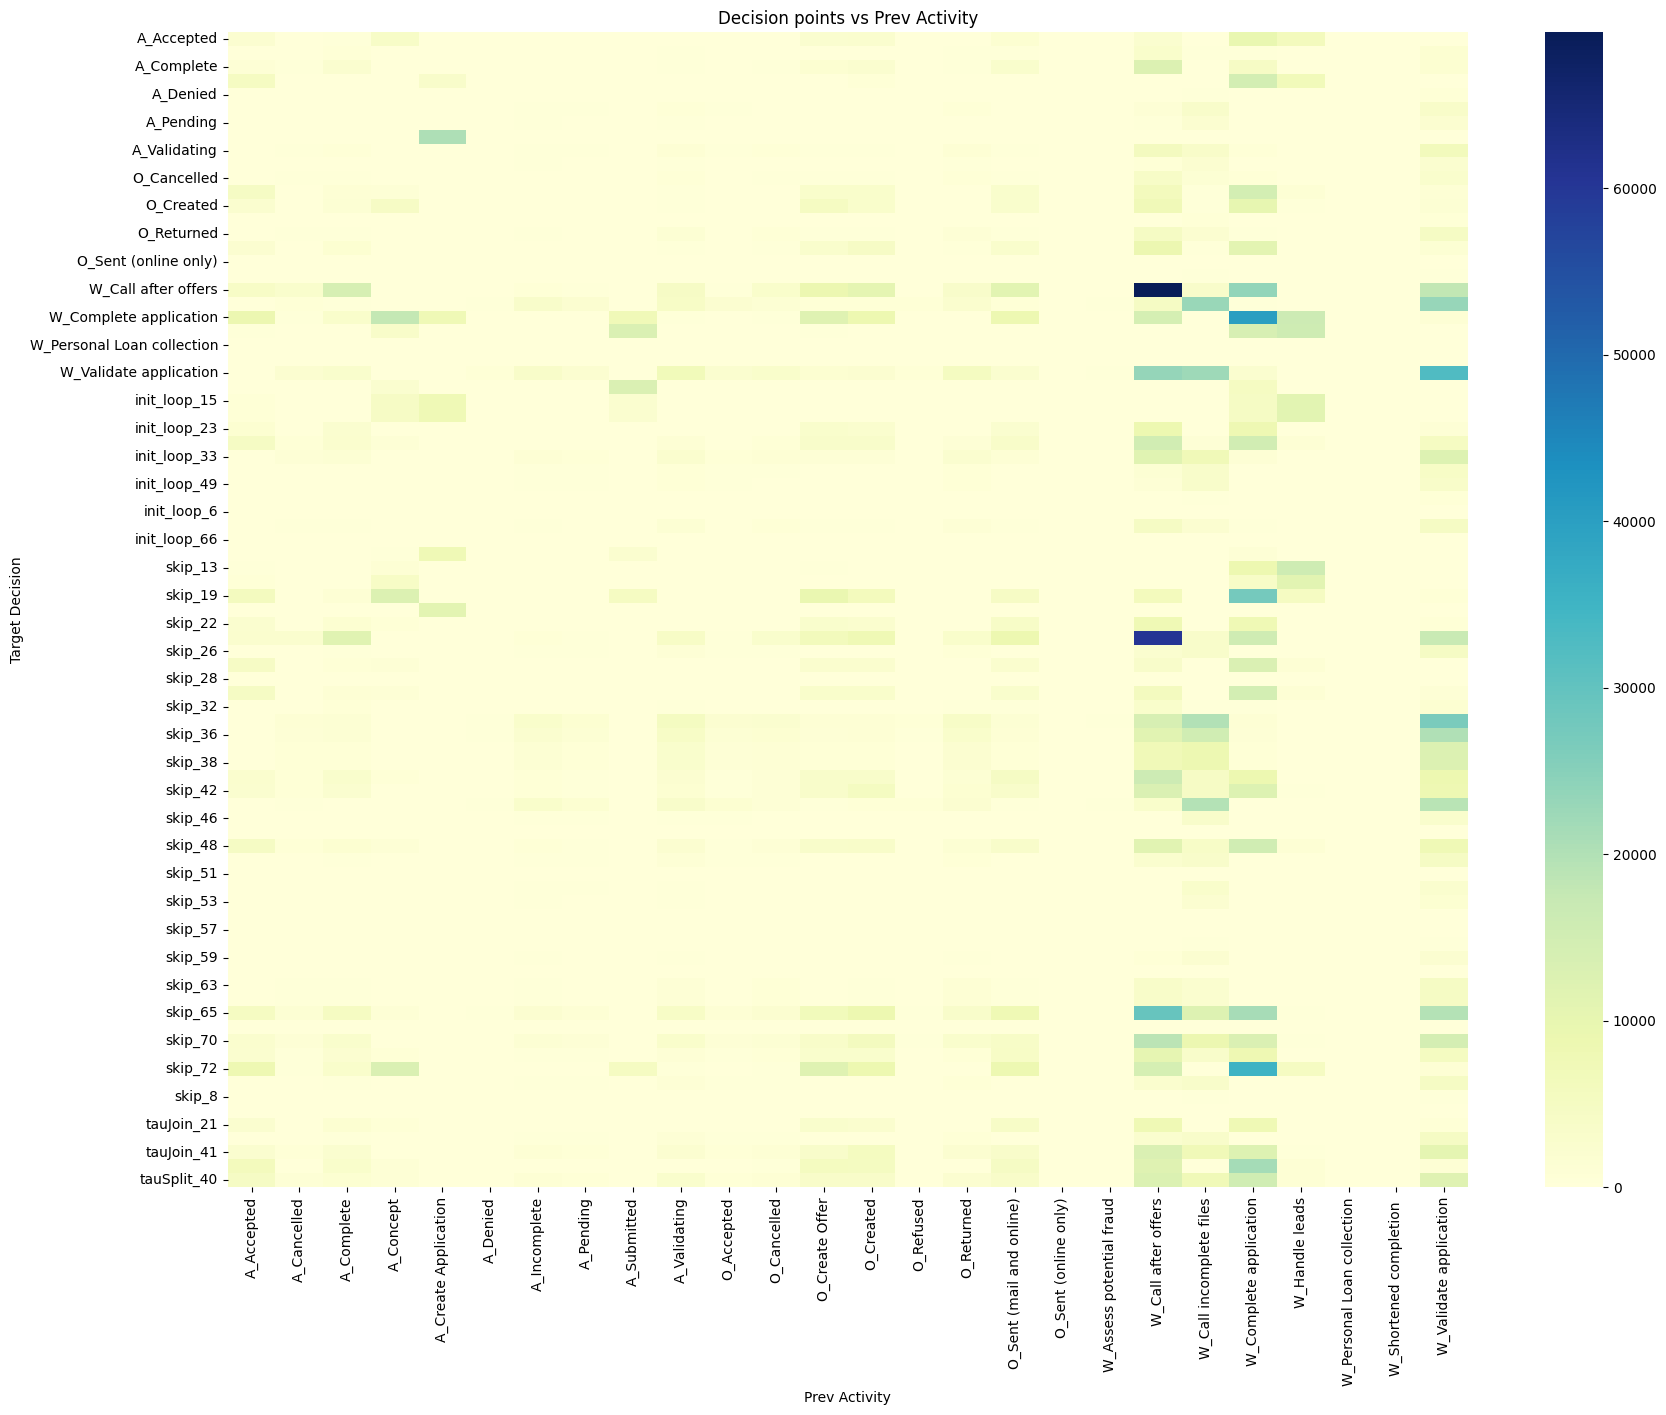

In [161]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 15)) # Boyutu verine göre ayarla
sns.heatmap(matrix_view, cmap="YlGnBu", annot=False) # annot=True yaparsan sayıları da yazar
plt.title("Decision points vs Prev Activity")
plt.xlabel("Prev Activity")
plt.ylabel("Target Decision")
plt.show()

Its time to use my C4.5 decision tree to train with df_xor_decisions

In [162]:
df_clean = df_xor_decisions[
    (df_xor_decisions['target_decision'].notna()) & 
    (df_xor_decisions['target_decision'] != "") &
    (~df_xor_decisions['target_decision'].str.contains('tau|skip|init|loop', case=False))
].copy()



In [163]:
counts = df_clean['target_decision'].value_counts()
significant_targets = counts[counts > 500].index
df_clean = df_clean[df_clean['target_decision'].isin(significant_targets)]

In [164]:
top_resources = df_clean['last_resource'].value_counts().nlargest(10).index
df_clean['resource_grouped'] = df_clean['last_resource'].apply(lambda x: x if x in top_resources else 'Other')

df_clean['duration_bin'], duration_bins= pd.qcut(df_clean['last_duration'], q=5, 
                                  labels=['VeryShort', 'Short', 'Medium', 'Long', 'VeryLong'], 
                                  duplicates='drop',
                                  retbins=True)

df_clean['case_age_category'], case_age_bins = pd.qcut(df_clean['case_duration_hours'], q=4, 
                                        labels=['Very_New', 'New', 'Old', 'Delayed'], 
                                        duplicates='drop'
                                        ,retbins=True)

In [165]:
def group_activity(act):
    s = str(act)
    if s.startswith('A_'): return 'Application_Phase'
    if s.startswith('O_'): return 'Offer_Phase'
    if s.startswith('W_'): return 'Workflow_Phase'
    return 'Other'

#df_clean['prev_activity_group'] = df_clean['prev_activity'].apply(group_activity)

Grouping didnt bring anything better

In [166]:
features = ["prev_activity", "resource_grouped", "duration_bin", "case_age_category"]
X = df_clean[features].astype(str)
y = df_clean["target_decision"]

In [167]:
attribute_types = {
    "prev_activity": "nominal",
    #"resource_grouped": "nominal",
    "duration_bin": "nominal",
    "case_age_category": "nominal"
}

In [168]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

final_tree = C45DecisionTree(attribute_types=attribute_types, max_depth=30, min_samples_split=10)
final_tree.fit(X_train, y_train)

In [169]:
y_pred = final_tree.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred):.4f}")

Accuracy: 0.3981
Balanced Accuracy: 0.1794


In [170]:
importance = final_tree.get_feature_importance()
print("\nFeature Importance:")
for feat, score in sorted(importance.items(), key=lambda x: x[1], reverse=True):
    print(f"{feat}: {score:.4f}")


Feature Importance:
case_age_category: 0.5752
prev_activity: 0.2876
duration_bin: 0.1372


The influence of resource group is too low --> delete it

I have to evaluate the performance of my decision tree

In [171]:
dots = final_tree.export_graphviz()
graph = graphviz.Source(dots)
graph

In [172]:
import pickle


In [173]:
sim_package = {
    "model": final_tree, 
    "bins": {
        "duration_bin": duration_bins.tolist() if hasattr(duration_bins, 'tolist') else duration_bins,
        "case_age_category": case_age_bins.tolist() if hasattr(case_age_bins, 'tolist') else case_age_bins
    }
}

with open("simulation_brain.pkl", "wb") as f:
    pickle.dump(sim_package, f)